In [ ]:
import pandas as pd
import numpy as np

# Loading
#data_set = pd.read_csv("drive/MyDrive/neural/adult.data")
data_set = pd.read_csv("drive/MyDrive/neural/Laptop_price.csv")

data_set = data_set.map(lambda x: x.strip() if isinstance(x, str) else x)

x =  data_set.iloc[:,:-1].values
y =  data_set.iloc[:,-1].values

feature = data_set.keys().map(lambda x: x.strip() if isinstance(x, str) else x)

# Filling
from sklearn.impute import SimpleImputer

cat_col_indices = [0]
for i in cat_col_indices:
    x[:, i] = np.where(x[:, i] == '?', np.nan, x[:, i])
    x[:, i] = SimpleImputer(strategy='most_frequent').fit_transform(x[:, i].reshape(-1,1)).ravel()

# Encoding
from sklearn.preprocessing import LabelEncoder
encoders = []
for i in range(x.shape[1]):
    le = LabelEncoder()
    x[:, i] = le.fit_transform(x[:, i])
    encoders.append(le)

# Normilizing
from sklearn.preprocessing import StandardScaler, MinMaxScaler
st_x= MinMaxScaler()
x = st_x.fit_transform(x)

st_y = MinMaxScaler()

y = y.reshape(-1,1)
y = st_y.fit_transform(y)



TRAIN_COEF = 0.7


TRAIN_COUNT = int(TRAIN_COEF * x.shape[0])
VAL_COUNT = x.shape[0] - TRAIN_COUNT

X_train_o = x[0:TRAIN_COUNT,:]
Y_train_o = y[0:TRAIN_COUNT]
X_val_o = x[TRAIN_COUNT:,:]
Y_val_o = y[TRAIN_COUNT:]


In [ ]:
y

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim


X_train = torch.tensor(X_train_o, dtype=torch.float32)
Y_train = torch.tensor(Y_train_o, dtype=torch.float32)

X_val = torch.tensor(X_val_o, dtype=torch.float32)
Y_val = torch.tensor(Y_val_o, dtype=torch.float32)

INPUT_SIZE = x.shape[1]
CLASSES_COUNT = 2

model = nn.Sequential(
            nn.Linear(INPUT_SIZE, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0002)


epochs = 100
batch_size = 8

In [ ]:
st_y.inverse_transform(np.array([[0]]))

array([[8570.01295047]])

Epoch 0, train_loss=0.050490 (5602.662765299407), val_loss=0.101666 (7950.2041871647925)
Epoch 10, train_loss=0.007017 (2088.6613282678454), val_loss=0.006403 (1995.2086616683657)
Epoch 20, train_loss=0.002922 (1347.8738922445539), val_loss=0.002970 (1358.9135807584187)
Epoch 30, train_loss=0.000851 (727.2413281077999), val_loss=0.001380 (926.4214227919475)
Epoch 40, train_loss=0.000246 (391.37236779487347), val_loss=0.000727 (672.1621304340052)
Epoch 50, train_loss=0.000112 (263.5051136698652), val_loss=0.000428 (515.7392753314208)
Epoch 60, train_loss=0.000080 (222.64376665836357), val_loss=0.000301 (432.85632332205313)
Epoch 70, train_loss=0.000079 (221.91781273054062), val_loss=0.000246 (390.9839200213707)
Epoch 80, train_loss=0.000071 (210.09615781300224), val_loss=0.000219 (369.2907521240055)
Epoch 90, train_loss=0.000069 (207.23217318953775), val_loss=0.000208 (359.6363246349837)


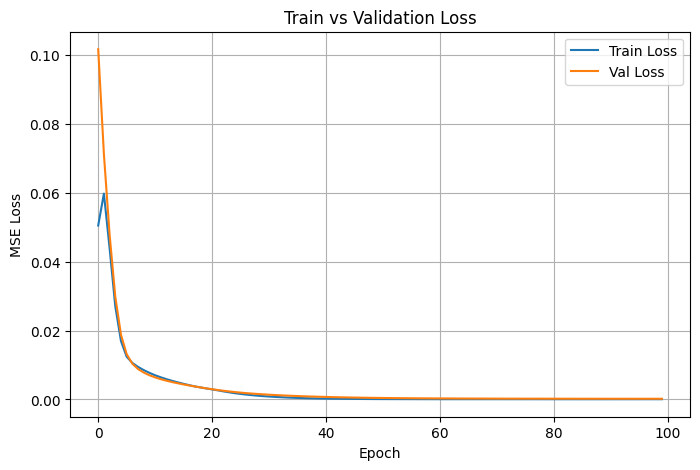

In [ ]:
import matplotlib.pyplot as plt

train_losses = []
val_losses = []

for epoch in range(epochs):
    for i in range(0, len(X_train), batch_size):
        X_batch = X_train[i:i+batch_size]
        y_batch = Y_train[i:i+batch_size]

        # forward
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        # backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    with torch.no_grad():
        val_outputs = model(X_val)
        val_loss = criterion(val_outputs, Y_val)


    train_losses.append(loss.item())
    val_losses.append(val_loss.item())

    if epoch % 10 == 0:
        y_min = st_y.data_min_[0]
        y_max = st_y.data_max_[0]

        train_rmse_norm = np.sqrt(loss.item())
        val_rmse_norm = np.sqrt(val_loss.item())

        # original format
        train_rmse_orig = train_rmse_norm * (y_max - y_min)
        val_rmse_orig = val_rmse_norm * (y_max - y_min)

        print(f"Epoch {epoch}, train_loss={loss.item():.6f} ({train_rmse_orig}), val_loss={val_loss.item():.6f} ({val_rmse_orig})")


plt.figure(figsize=(8,5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Train vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()



In [ ]:
#Corr matrix
n_samples, n_features = x.shape
corr_matrix = np.zeros((n_features, n_features))

x = x.astype(float)

means = np.mean(x, axis=0)
stds = np.std(x, axis=0, ddof=0)

for i in range(n_features):
    for j in range(n_features):
        cov = np.sum((x[:, i] - means[i]) * (x[:, j] - means[j])) / n_samples
        corr_matrix[i, j] = cov / (stds[i] * stds[j])
corr_matrix = np.corrcoef(x, rowvar=False)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, xticklabels=feature[:-1], yticklabels=feature[:-1])
plt.title('Correlation')
plt.show()

In [ ]:
import numpy as np

class NeuralNetworkRegressor:
    def __init__(self, input_size, h_size, out_size, X_train, Y_train, X_val=None, Y_val=None):
        self.X_train = X_train
        self.Y_train = Y_train.reshape(-1, out_size)
        self.X_val = X_val
        self.Y_val = Y_val.reshape(-1, out_size) if Y_val is not None else None

        self.W1 = np.random.randn(input_size, h_size) * 0.01
        self.b1 = np.zeros((1, h_size))
        self.W2 = np.random.randn(h_size, out_size) * 0.01
        self.b2 = np.zeros((1, out_size))

        self.out_size = out_size

        self.ALPHA = 0.002
        self.epochs = 1000
        self.batch_size = 32

    def forward(self, x):
        t1 = x @ self.W1 + self.b1
        h1 = self.relu(t1)
        t2 = h1 @ self.W2 + self.b2
        return t1, h1, t2

    def predict(self, x):
        _, _, y_pred = self.forward(x)
        return y_pred

    def relu(self, t):
        return np.maximum(t, 0)

    def relu_deriv(self, t):
        return (t > 0).astype(float)

    def mse(self, y_pred, y):
        return np.mean((y_pred - y) ** 2)

    def compute_loss(self, X, y):
        _, _, y_pred = self.forward(X)
        return self.mse(y_pred, y)

    def train(self):
        train_losses = []
        val_losses = []

        for epoch in range(self.epochs):
            indices = np.random.permutation(len(self.X_train))
            self.X_train = self.X_train[indices]
            self.Y_train = self.Y_train[indices]

            epochE = 0

            for i in range(0, len(self.X_train), self.batch_size):
                X_batch = self.X_train[i:i+self.batch_size]
                y_batch = self.Y_train[i:i+self.batch_size]

                t1, h1, y_pred = self.forward(X_batch)

                E = self.mse(y_pred, y_batch)

                # backward
                dE_dy = 2 * (y_pred - y_batch) / len(y_batch)

                dE_dW2 = h1.T @ dE_dy
                dE_db2 = np.sum(dE_dy, axis=0, keepdims=True)

                dE_dh1 = dE_dy @ self.W2.T
                dE_dt1 = dE_dh1 * self.relu_deriv(t1)

                dE_dW1 = X_batch.T @ dE_dt1
                dE_db1 = np.sum(dE_dt1, axis=0, keepdims=True)

                self.W1 -= self.ALPHA * dE_dW1
                self.b1 -= self.ALPHA * dE_db1
                self.W2 -= self.ALPHA * dE_dW2
                self.b2 -= self.ALPHA * dE_db2

                epochE += E

            train_loss = epochE / (len(self.X_train) / self.batch_size)
            train_losses.append(train_loss)

            if self.X_val is not None:
                val_loss = self.compute_loss(self.X_val, self.Y_val)
                val_losses.append(val_loss)
            else:
                val_loss = None

            if epoch % 10 == 0:
                print(f"Epoch {epoch}, train_loss={train_loss:.6f}, val_loss={val_loss:.6f}")

        return train_losses, val_losses


Epoch 0, train_loss=0.326119, val_loss=0.300005
Epoch 10, train_loss=0.174170, val_loss=0.165144
Epoch 20, train_loss=0.147662, val_loss=0.143011
Epoch 30, train_loss=0.143283, val_loss=0.139275
Epoch 40, train_loss=0.141880, val_loss=0.138302
Epoch 50, train_loss=0.140767, val_loss=0.137565
Epoch 60, train_loss=0.139770, val_loss=0.136663
Epoch 70, train_loss=0.138805, val_loss=0.135501
Epoch 80, train_loss=0.137187, val_loss=0.134009
Epoch 90, train_loss=0.135340, val_loss=0.132108
Epoch 100, train_loss=0.132921, val_loss=0.129709
Epoch 110, train_loss=0.129833, val_loss=0.126706
Epoch 120, train_loss=0.125879, val_loss=0.122986
Epoch 130, train_loss=0.121501, val_loss=0.118429
Epoch 140, train_loss=0.115789, val_loss=0.112931
Epoch 150, train_loss=0.109117, val_loss=0.106427
Epoch 160, train_loss=0.101413, val_loss=0.098913
Epoch 170, train_loss=0.092609, val_loss=0.090461
Epoch 180, train_loss=0.083143, val_loss=0.081246
Epoch 190, train_loss=0.073123, val_loss=0.071574
Epoch 200, 

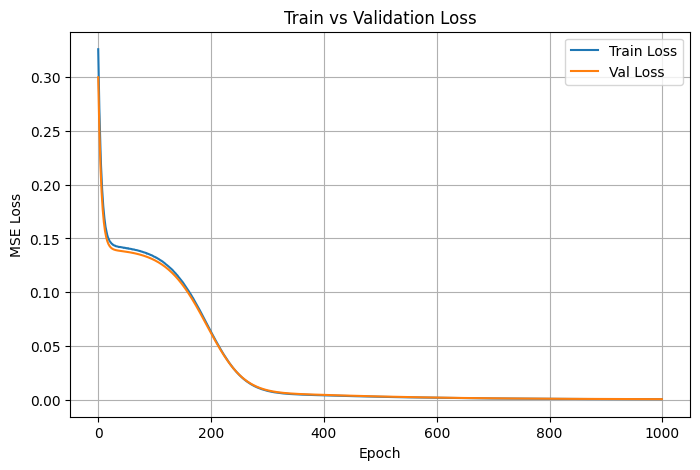

In [ ]:
import matplotlib.pyplot as plt


net = NeuralNetworkRegressor(
    input_size=x.shape[1],
    h_size=64,
    out_size=1,
    X_train=X_train_o, Y_train=Y_train_o, X_val=X_val_o, Y_val=Y_val_o
    )

net_losses,net_val_losses = net.train()


plt.figure(figsize=(8,5))
plt.plot(net_losses, label='Train Loss')
plt.plot(net_val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Train vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()